In [7]:
import matplotlib.pyplot as plt
import numpy as np
from pyiron_base import Project

In [8]:
from pyiron_glass import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

In [9]:
pr = Project("test1")
atoms_dict = get_structure_dict(
    comp="0.25CaO-0.25Al2O3-0.50SiO2", 
    n_molecules=200, 
    density=2.69*1.0, 
    min_distance=1.8, 
    max_attempts_per_atom = 10000,
    pyiron_project=pr,
)
structure = get_ase_structure(atoms_dict=atoms_dict, pyiron_project=pr,)
potential = generate_potential(atoms_dict=atoms_dict, pyiron_project=pr,)

In [10]:
delayed = melt_quench_simulation(
    structure=structure, 
    potential=potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    working_directory="lmp_tmp_directory",
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    pyiron_project=pr,
)

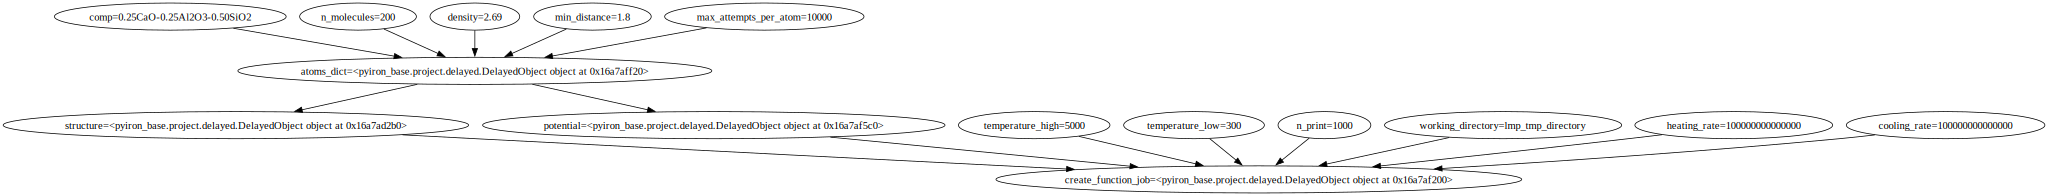

In [11]:
delayed.draw()

In [12]:
result = delayed.pull()

The job get_structure_dict_5c86e4a3585f2da7cd7b171befd095df was saved and received the ID: 441
The job get_ase_structure_0443e7dc521069062a872f662912cb1f was saved and received the ID: 442
The job generate_potential_9f920ae3e7ec680a7b8309d3a27d57ae was saved and received the ID: 443
The job melt_quench_simulation_4628bb6a6d4e318514d0844c3f1db244 was saved and received the ID: 444


/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)
/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='o

In [7]:
# NBVAL_CHECK_OUTPUT
print(f"{np.mean(result["temperature"]):.1f} K")

300.1 K


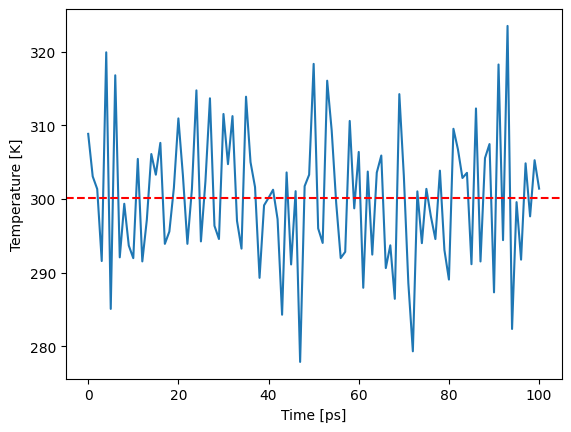

In [8]:
plt.plot(result["steps"]*1e-3, result["temperature"])
plt.axhline(np.mean(result["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");

In [9]:
print(result["structure"])

Atoms(symbols='Al100Ca50O400Si100', pbc=True, cell=[[20.20586602368216, 3.711757372485392e-15, 3.711757372485392e-15], [-2.4745049149067213e-15, 20.205866023, 3.711757372360081e-15], [-2.47450491490672e-15, -2.4745049149067213e-15, 20.205866023]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)
